In [ ]:
# Basic utilities
import os
import sys
import time
import random
import numpy as np
import pandas as pd

# OpenCV for image processing
import cv2

# Matplotlib for plotting/visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras for CNN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sklearn for preprocessing & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Optional: For advanced training pipelines
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))


['Colab Notebooks', 'Runway_Prediction_Dataset']


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Runway_Prediction_Dataset"
print(os.listdir(DATASET_PATH))


['dataset_runway', 'dataset_soccer', 'city']


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Runway_Prediction_Dataset"

class_map = {
    "dataset_runway": 0,   # runway
    "dataset_soccer": 1,   # football field
    "city": 2              # city (not safe)
}

IMG_SIZE = 224


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

DATASET_PATH = "/content/drive/MyDrive/Runway_Prediction_Dataset"

class_map = {
    "dataset_runway": 0,
    "dataset_soccer": 1,
    "city": 2
}

X = []
y = []

for folder, label in class_map.items():
    folder_path = os.path.join(DATASET_PATH, folder)
    print("Reading:", folder_path)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Total images:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)


Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/dataset_runway
Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/dataset_soccer
Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/city
Total images: 5557
X shape: (5557, 224, 224, 3)
y shape: (5557,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (4445, 224, 224, 3) (4445,)
Test : (1112, 224, 224, 3) (1112,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 3


In [ ]:
CLASSES = ["dataset_runway", "dataset_soccer", "city"]


In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 128
DATASET_PATH = "/content/drive/MyDrive/Runway_Prediction_Dataset"


In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 128
DATASET_PATH = "/content/drive/MyDrive/Runway_Prediction_Dataset"

CLASSES = ["dataset_runway", "dataset_soccer", "city"]

X = []
y = []

for label, folder in enumerate(CLASSES):
    path = os.path.join(DATASET_PATH, folder)
    print("Reading:", path)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Total images:", X.shape, y.shape)


Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/dataset_runway
Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/dataset_soccer
Reading: /content/drive/MyDrive/Runway_Prediction_Dataset/city
Total images: (5557, 128, 128, 3) (5557,)


In [ ]:
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 3

y_encoded = to_categorical(y, NUM_CLASSES)

print("Before:", y[:10])
print("After one-hot:", y_encoded[:10])


Before: [0 0 0 0 0 0 0 0 0 0]
After one-hot: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (4445, 128, 128, 3) (4445, 3)
Test: (1112, 128, 128, 3) (1112, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')   # 3 classes
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
EPOCHS = 125
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test)
)


Epoch 1/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8276 - loss: 0.4859 - val_accuracy: 0.9622 - val_loss: 0.0901
Epoch 2/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9725 - loss: 0.0907 - val_accuracy: 0.9856 - val_loss: 0.0397
Epoch 3/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9881 - loss: 0.0380 - val_accuracy: 0.9955 - val_loss: 0.0209
Epoch 4/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9961 - loss: 0.0213 - val_accuracy: 0.9577 - val_loss: 0.2273
Epoch 5/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9752 - loss: 0.1057 - val_accuracy: 0.9937 - val_loss: 0.0120
Epoch 6/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9940 - loss: 0.0211 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 7/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9935 - loss: 0.0226 - val_accuracy: 0.9406 - val_loss: 0.1478
Epoch 8/125
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9732 - loss: 0.1330 -

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0330
Test Accuracy: 0.9973021745681763


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


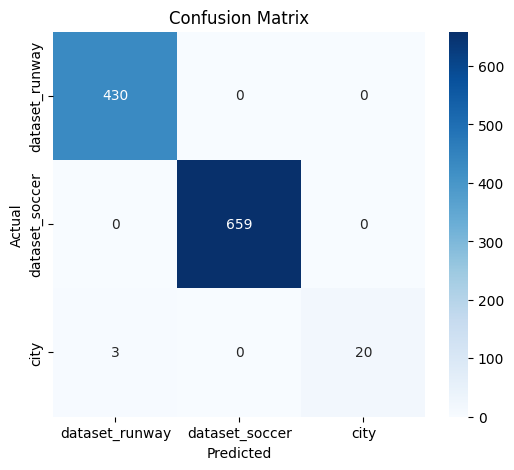

                precision    recall  f1-score   support

dataset_runway       0.99      1.00      1.00       430
dataset_soccer       1.00      1.00      1.00       659
          city       1.00      0.87      0.93        23

      accuracy                           1.00      1112
     macro avg       1.00      0.96      0.98      1112
  weighted avg       1.00      1.00      1.00      1112



In [ ]:
# ===== Evaluation on Test Set =====
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=CLASSES))


In [ ]:
CLASSES = ['runway', 'football_field', 'city']
IMG_SIZE = 128


In [ ]:
from google.colab import files
uploaded = files.upload()   # choose image from your PC


Saving 1637.png to 1637.png


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 128

img_path = list(uploaded.keys())[0]   # get uploaded filename

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
img = np.expand_dims(img, axis=0)

print("✅ Image loaded:", img.shape)


✅ Image loaded: (1, 128, 128, 3)


In [ ]:
pred = model.predict(img)[0]

CLASSES = ['runway', 'football_field', 'city']

print("\nProbabilities:")
for i, c in enumerate(CLASSES):
    print(f"{c}: {pred[i]*100:.2f}%")

top1 = np.argmax(pred)
confidence = pred[top1] * 100
sorted_idx = np.argsort(pred)[::-1]
margin = (pred[sorted_idx[0]] - pred[sorted_idx[1]]) * 100

print("\nFinal Decision:")

if top1 == 0 and confidence > 80 and margin > 25:
    print("✅ RUNWAY — SAFE TO LAND")

elif top1 == 1 and confidence > 70:
    print("⚠ FOOTBALL FIELD — EMERGENCY LANDING ONLY")

else:
    print("❌ NOT SAFE TO LAND (CITY / UNCERTAIN)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step

Probabilities:
runway: 0.00%
football_field: 100.00%
city: 0.00%

Final Decision:
⚠ FOOTBALL FIELD — EMERGENCY LANDING ONLY


SOME COOL SHIT DATA

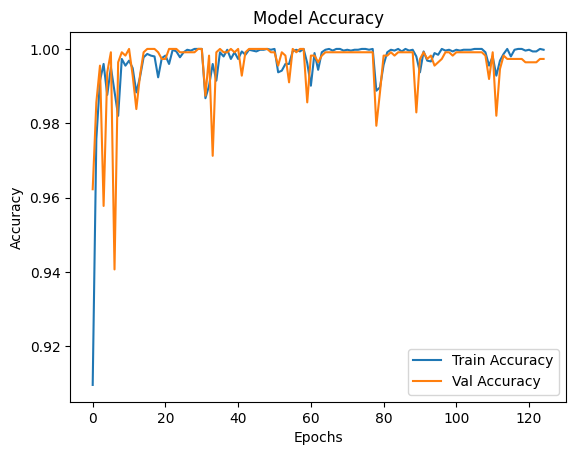

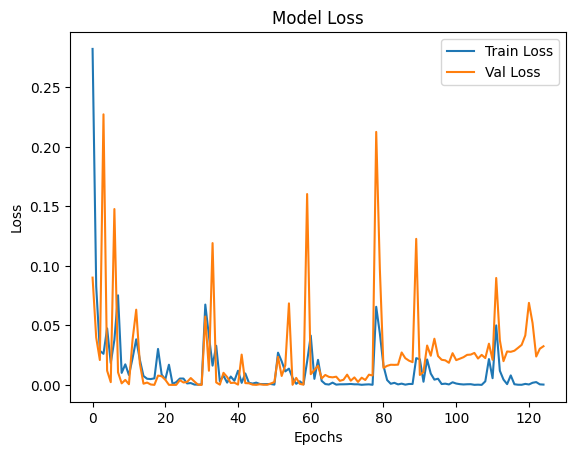

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save('/content/drive/MyDrive/runway_landing_model.keras')
print("Model saved to Drive ✅")


Model saved to Drive ✅


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/runway_landing_model.keras')
print("Model loaded successfully ✅")


Model loaded successfully ✅
